In [1]:
import glob 
import os
import numpy as np

from data_utils import parse_p2s, load_s_e_l_segs, segment_lengths, generate_more_segments, split_eat_noneat

from tqdm import tqdm

In [2]:
def find_all_labelled_files(root_dir):
    files=glob.glob(root_dir+"/*")
    for file in files:
        if "toupload" in file:
            files.remove(file)
    # print(files)

    segments_files=[]

    file=files[0]
    for file in files:
        segments_all=glob.glob(file+"/**/segments.txt",recursive=True) 
        for segment in segments_all:
            if "cam1" in segment and not "pill" in segment:
                segments_files.append(segment)

    len(segments_files)

     
    dir_segs={}
    for filename in segments_files:
        try:
            dir_segs[filename]=load_s_e_l_segs(filename)
        except Exception as e:
            print("Error in loading file", filename)
            print(e)
            print('-------------------')
    return dir_segs

### Loading Test data

In [3]:
# test_dir="/media/ns/Seagate/oct18"
test_dir="/media/ns/Seagate/oct25"

In [4]:
dir_segs=find_all_labelled_files(test_dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 4


In [5]:
# seg_files=list(dir_segs.keys())
# seg_files

In [6]:
eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs)
print(f"Total eating segments: {sum([len(v) for v in eating_file2segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_file2segs.values()])}")

Total eating segments: 13
Total not eating segments: 15


In [7]:
de=segment_lengths(eating_file2segs)
dne=segment_lengths(not_eating_file2segs)

print(f"Total eating segments: {len(de)}")
print(f"Total not eating segments: {len(dne)}")

print(f"min eating segment: {min(de)}")
print(f"max eating segment: {max(de)}") 
print(f"min not eating segment: {min(dne)}")
print(f"max not eating segment: {max(dne)}")
print(f"median eating segment: {np.median(de)}")
print(f"median not eating segment: {np.median(dne)}")

Total eating segments: 13
Total not eating segments: 15
min eating segment: 41
max eating segment: 677
min not eating segment: 32
max not eating segment: 382
median eating segment: 210.0
median not eating segment: 112.0


In [8]:
seq_length=30

eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=10)
not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=10)

print('Fixed length segments: ', seq_length)
print(f"Total eating segments: {sum([len(v) for v in eating_segs.values()])}")
print(f"Total not eating segments: {sum([len(v) for v in not_eating_segs.values()])}")

Fixed length segments:  30
Total eating segments: 169
Total not eating segments: 85


In [9]:
#create dataset
all_rows_eating=[]
for filepath in eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_eating.append(rows)

all_rows_eating=np.concatenate(all_rows_eating, axis=0)

all_rows_not_eating=[]
for filepath in not_eating_segs.keys():
    dirname=os.path.dirname(filepath)
    ses=parse_p2s(dirname)
    fixed_segs=not_eating_segs[filepath]
    rows=np.array([ses[s:e] for s,e in fixed_segs] )
    all_rows_not_eating.append(rows)
all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

all_rows_eating.shape, all_rows_not_eating.shape

((169, 30, 50), (85, 30, 50))

In [10]:
X_test=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
y_test=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
X_test.shape, y_test.shape

((254, 30, 50), (254,))

### Loading training data

In [11]:
# filepath_oct25="/media/ns/Seagate/oct25"
filepath_nov6="/media/ns/Seagate/nov6"
filepath_nov8="/media/ns/Seagate/nov8"
filepath_nov15="/media/ns/Seagate/nov15"

In [ ]:
# files_oct25=glob.glob(filepath_oct25+"/*")
# for file in files_oct25:
#     if 'toupload' in file:
#         del files_oct25[files_oct25.index(file)]
# files_oct25

In [13]:
files_nov6=glob.glob(filepath_nov6+"/*")
for file in files_nov6:
    #if it is a file
    if os.path.isfile(file):
        del files_nov6[files_nov6.index(file)]
    if 'toupload' in file:
        del files_nov6[files_nov6.index(file)] 
for file in files_nov6: 
    if 'need' in file: 
        del files_nov6[files_nov6.index(file)]
for file in files_nov6: 
    if 'labelled' in file: 
        del files_nov6[files_nov6.index(file)]
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/katie',
 '/media/ns/Seagate/nov6/katy',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/ashley',
 '/media/ns/Seagate/nov6/makalyah',
 '/media/ns/Seagate/nov6/ana']

In [14]:
len(files_nov6)

10

In [15]:
#remove issues.
issues=['katy', 'katie', 'ana', 'ashley']
for issue in issues:
    for file in files_nov6:
        if issue in file:
            del files_nov6[files_nov6.index(file)]
            
files_nov6

['/media/ns/Seagate/nov6/joey',
 '/media/ns/Seagate/nov6/lucy',
 '/media/ns/Seagate/nov6/patrick',
 '/media/ns/Seagate/nov6/corinna',
 '/media/ns/Seagate/nov6/jessie',
 '/media/ns/Seagate/nov6/makalyah']

In [16]:

files_nov8=glob.glob(filepath_nov8+"/*")
for file in files_nov8:
    if 'toupload' in file:
        del files_nov8[files_nov8.index(file)]
files_nov8

['/media/ns/Seagate/nov8/anna', '/media/ns/Seagate/nov8/jack']

In [17]:
files_nov15=glob.glob(filepath_nov15+"/*")
for file in files_nov15:
    if 'toupload' in file:
        del files_nov15[files_nov15.index(file)]
for file in files_nov15: 
    if 'need' in file: 
        del files_nov15[files_nov15.index(file)]
files_nov15

['/media/ns/Seagate/nov15/sheikh',
 '/media/ns/Seagate/nov15/hafizul',
 '/media/ns/Seagate/nov15/rabiul']

In [19]:
all_files= files_nov6+files_nov8+files_nov15
len(all_files)

11

In [20]:
dir=all_files[0]
dir_segs=find_all_labelled_files(dir)
print(f"Total segments.txt files found: {len(dir_segs)}")

Total segments.txt files found: 2


In [21]:
dir_segs_all={}
for dir in all_files:
    dir_segs=find_all_labelled_files(dir)
    print('dir=', dir)
    print(f"Total segments.txt files found: {len(dir_segs)}\n") 
    for k,v in dir_segs.items():
        dir_segs_all[k]=v

len(dir_segs_all)

dir= /media/ns/Seagate/nov6/joey
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/lucy
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/patrick
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/corinna
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/jessie
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov6/makalyah
Total segments.txt files found: 3

dir= /media/ns/Seagate/nov8/anna
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov8/jack
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/sheikh
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/hafizul
Total segments.txt files found: 2

dir= /media/ns/Seagate/nov15/rabiul
Total segments.txt files found: 2



23

In [22]:
keys=list(dir_segs_all.keys())
keys_base=keys[:10]
keys_1=keys[10:13]
keys_2=keys[13:16]
keys_3=keys[16:19]
keys_4=keys[19:24] 

dir_segs_base={k:dir_segs_all[k] for k in keys_base}
dir_segs_1={k:dir_segs_all[k] for k in keys_base+keys_1}
dir_segs_2={k:dir_segs_all[k] for k in keys_base+keys_1+keys_2}
dir_segs_3={k:dir_segs_all[k] for k in keys_base+keys_1+keys_2+keys_3}
dir_segs_4={k:dir_segs_all[k] for k in keys_base+keys_1+keys_2+keys_3+keys_4}

len(dir_segs_base), len(dir_segs_1), len(dir_segs_2), len(dir_segs_3), len(dir_segs_4), len(dir_segs_all)

(10, 13, 16, 19, 23, 23)

In [23]:
seq_length=30

In [24]:
def create_dataset(eating_segs, not_eating_segs):
    all_rows_eating=[]
    for filepath in eating_segs.keys():
        dirname=os.path.dirname(filepath)
        ses=parse_p2s(dirname)
        fixed_segs=eating_segs[filepath]
        rows=np.array([ses[s:e] for s,e in fixed_segs] )
        all_rows_eating.append(rows)

    all_rows_eating=np.concatenate(all_rows_eating, axis=0)

    all_rows_not_eating=[]
    for filepath in not_eating_segs.keys():
        dirname=os.path.dirname(filepath)
        ses=parse_p2s(dirname)
        fixed_segs=not_eating_segs[filepath]
        rows=np.array([ses[s:e] for s,e in fixed_segs] )
        all_rows_not_eating.append(rows)
    all_rows_not_eating=np.concatenate(all_rows_not_eating, axis=0)

    return all_rows_eating, all_rows_not_eating 

In [25]:
def generate_Xy(dir_segs_all):
    eating_file2segs, not_eating_file2segs=split_eat_noneat(dir_segs_all)
    eating_segs=generate_more_segments(eating_file2segs, seq_length=seq_length, max_overlap=10)
    not_eating_segs=generate_more_segments(not_eating_file2segs, seq_length=seq_length, max_overlap=10)

    all_rows_eating, all_rows_not_eating = create_dataset(eating_segs, not_eating_segs)

    X_train=np.concatenate([all_rows_eating, all_rows_not_eating], axis=0)
    y_train=np.concatenate([np.ones(all_rows_eating.shape[0]), np.zeros(all_rows_not_eating.shape[0])], axis=0)
    return X_train, y_train

In [26]:
X_train_base, y_train_base=generate_Xy(dir_segs_base)
X_train_1, y_train_1=generate_Xy(dir_segs_1)
X_train_2, y_train_2=generate_Xy(dir_segs_2)
X_train_3, y_train_3=generate_Xy(dir_segs_3)
X_train_4, y_train_4=generate_Xy(dir_segs_4)

X_train_base.shape, y_train_base.shape, X_train_1.shape, y_train_1.shape, X_train_2.shape, y_train_2.shape, X_train_3.shape, y_train_3.shape, X_train_4.shape, y_train_4.shape

((469, 30, 50),
 (469,),
 (572, 30, 50),
 (572,),
 (660, 30, 50),
 (660,),
 (801, 30, 50),
 (801,),
 (922, 30, 50),
 (922,))

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import glob 
import torch
import torch.nn as nn
import torch.optim as optim 
import time 
from torch.utils.data import DataLoader, TensorDataset

In [28]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
device 

device(type='cuda')

In [29]:
# test_loader = DataLoader(
#     TensorDataset(torch.tensor(X_test, dtype=torch.float32), torch.tensor(y_test, dtype=torch.float32)),
#     batch_size=32, shuffle=True)

X_test_tensor=torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_tensor=torch.tensor(y_test, dtype=torch.float32).to(device)
X_test_tensor.shape, y_test_tensor.shape

(torch.Size([254, 30, 50]), torch.Size([254]))

In [30]:
class LSTM(nn.Module):
    
    def __init__(self,input_dim,hidden_dim,output_dim,layer_num, seq_len):
        super(LSTM,self).__init__()
        self.hidden_dim = hidden_dim
        self.output_dim = output_dim
        self.lstm = torch.nn.LSTM(input_dim,hidden_dim,layer_num,batch_first=True)
        self.fc = torch.nn.Linear(hidden_dim,output_dim)
        self.bn = nn.BatchNorm1d(seq_len)
        
    def forward(self,inputs):
        x = self.bn(inputs)
        lstm_out,(hn,cn) = self.lstm(x)
        out = self.fc(lstm_out[:,-1,:])
        return out

### Train base

In [31]:
n_hidden = 128
n_joints = 25*2
n_categories = 2
n_layer = 3
seq_len = 30

n_iters = 5_000
print_every = 100

learning_rate = 1e-5 

In [32]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_base, dtype=torch.float32), torch.tensor(y_train_base, dtype=torch.float32)),
    batch_size=64, shuffle=True)

  2%|▏         | 101/5000 [00:10<06:33, 12.44it/s]

100 4.830036282539368


  4%|▍         | 201/5000 [00:18<06:07, 13.05it/s]

200 4.163010954856873


  6%|▌         | 301/5000 [00:26<06:22, 12.29it/s]

...

4800 0.19221758842468262


 98%|█████████▊| 4902/5000 [05:14<00:05, 17.03it/s]

4900 0.19474830944091082


100%|██████████| 5000/5000 [05:20<00:00, 15.58it/s]


5000 0.1875092713162303
acc= 0.5984252095222473


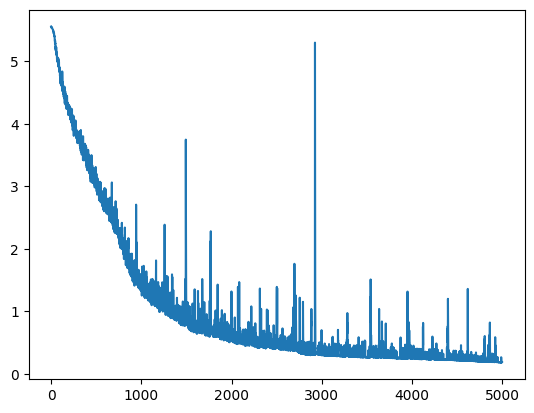

In [33]:
rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)


rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train base+keys1

  0%|          | 0/5000 [00:00<?, ?it/s]

  2%|▏         | 101/5000 [00:06<05:38, 14.48it/s]

100 5.6683250069618225


  4%|▍         | 201/5000 [00:12<06:00, 13.30it/s]

200 4.938649773597717


...

4800 0.005418128901510499


 98%|█████████▊| 4902/5000 [05:39<00:07, 12.67it/s]

4900 0.008854263433022425


100%|██████████| 5000/5000 [05:46<00:00, 14.43it/s]


5000 0.0070955336559563875
acc= 0.6299212574958801


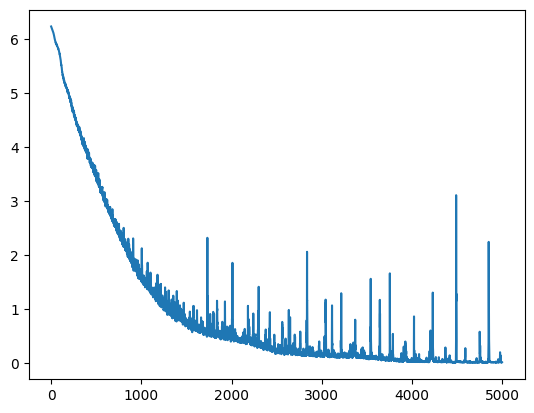

In [34]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_1, dtype=torch.float32), torch.tensor(y_train_1, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)


all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train keys2

  0%|          | 0/5000 [00:00<?, ?it/s]

  2%|▏         | 100/5000 [00:08<07:30, 10.88it/s]

100 6.746769547462463


  4%|▍         | 201/5000 [00:17<07:37, 10.49it/s]

200 5.7397540509700775


...

4800 0.020514025585725904


 98%|█████████▊| 4901/5000 [07:16<00:10,  9.83it/s]

4900 0.007915310765383765


100%|██████████| 5000/5000 [07:26<00:00, 11.21it/s]


5000 0.03311600157758221
acc= 0.5905511975288391


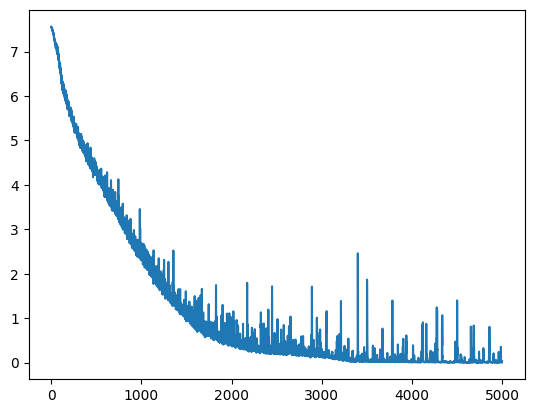

In [35]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_2, dtype=torch.float32), torch.tensor(y_train_2, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)


all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train keys3

  0%|          | 0/5000 [00:00<?, ?it/s]

  2%|▏         | 101/5000 [00:10<09:07,  8.95it/s]

100 8.019957900047302


  4%|▍         | 201/5000 [00:20<09:01,  8.87it/s]

200 6.868042886257172


...

4800 0.01192712871124968


 98%|█████████▊| 4901/5000 [08:30<00:12,  8.13it/s]

4900 0.01047327448031865


100%|██████████| 5000/5000 [08:41<00:00,  9.60it/s]


5000 0.06523367360932752
acc= 0.6574802994728088


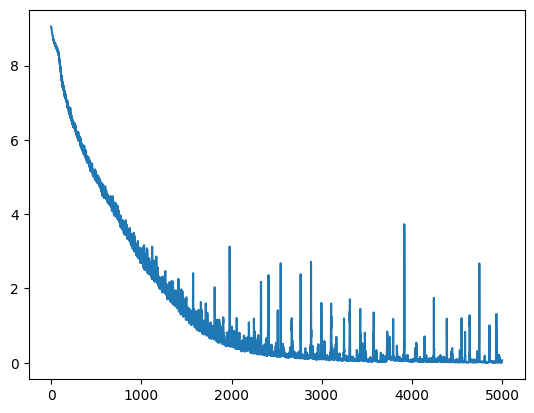

In [36]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_3, dtype=torch.float32), torch.tensor(y_train_3, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

### Train keys4

  0%|          | 0/5000 [00:00<?, ?it/s]

  2%|▏         | 101/5000 [00:12<07:55, 10.31it/s]

100 9.019396960735321


  4%|▍         | 200/5000 [00:22<07:39, 10.44it/s]

200 8.02982011437416


...

4800 0.005701592308469117


 98%|█████████▊| 4901/5000 [09:49<00:11,  8.37it/s]

4900 0.00613815248652827


100%|██████████| 5000/5000 [10:00<00:00,  8.33it/s]

5000 0.007590451554278843
acc= 0.6062992215156555


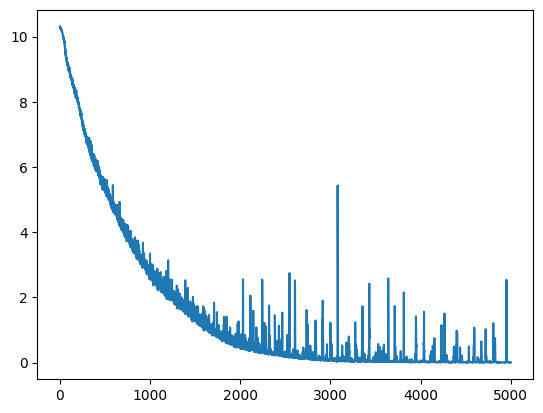

In [37]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_4, dtype=torch.float32), torch.tensor(y_train_4, dtype=torch.float32)),
    batch_size=64, shuffle=True)

rnn = LSTM(n_joints,n_hidden,n_categories,n_layer, seq_len)
rnn.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(rnn.parameters(),lr=learning_rate)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        rnn.zero_grad()
        output = rnn(data)
        loss = criterion(output, target.long())
        loss.backward()
        optimizer.step()
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses)

rnn.eval()
with torch.no_grad():
    y_pred=rnn(X_test_tensor)
    y_pred=y_pred.argmax(dim=1)
    acc=(y_pred==y_test_tensor).float().mean()
    print('acc=', acc.item())

In [39]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class TransformerClassifier(nn.Module):
    def __init__(self, feature_dim, seq_len, d_model, nhead, num_layers, num_classes=1):
        super(TransformerClassifier, self).__init__()
        self.embedding = nn.Linear(feature_dim, d_model)
        self.positional_encoding = nn.Parameter(torch.zeros(1, seq_len, d_model))
        self.transformer = nn.TransformerEncoder(
            nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead),
            num_layers=num_layers
        )
        self.pooling = nn.AdaptiveAvgPool1d(1)
        self.fc = nn.Linear(d_model, num_classes)
    
    def forward(self, x):
        # x: (batch_size, seq_len, feature_dim)
        x = self.embedding(x)  # (batch_size, seq_len, d_model)
        x += self.positional_encoding  # Add positional encoding
        x = x.permute(1, 0, 2)  # Transformer expects (seq_len, batch_size, d_model)
        x = self.transformer(x)  # (seq_len, batch_size, d_model)
        x = x.permute(1, 2, 0)  # Back to (batch_size, d_model, seq_len)
        x = self.pooling(x).squeeze(-1)  # (batch_size, d_model)
        x = self.fc(x)  # (batch_size, num_classes)
        return x


In [40]:
# Define the model
feature_dim = 50
seq_len = 30
d_model = 128
nhead = 4
num_layers = 2
num_classes = 1  # Binary classification

model = TransformerClassifier(feature_dim, seq_len, d_model, nhead, num_layers, num_classes)

# Test the model
inputs = torch.randn(254, 30, 50)  # (batch_size, seq_len, feature_dim)
outputs = model(inputs)  # (batch_size, num_classes)
print(outputs.shape)  # Expected: torch.Size([254, 1])

torch.Size([254, 1])


In [42]:
train_loader =  DataLoader(
    TensorDataset(torch.tensor(X_train_4, dtype=torch.float32), torch.tensor(y_train_4, dtype=torch.float32)),
    batch_size=64, shuffle=True)

model = TransformerClassifier(feature_dim, seq_len, d_model, nhead, num_layers, num_classes)
model.to(device)

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

all_losses = []
for iter in tqdm( range(1, n_iters + 1) ):
    
    current_loss = 0
    for j, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        
        outputs = model(data).squeeze(-1)  # (batch_size,)
        loss = criterion(outputs, target)
        
        
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        current_loss += loss.item()
        
    all_losses.append(current_loss)
    if iter % print_every == 0:
        print(f'{iter} {current_loss}') 

plt.plot(all_losses) 

  2%|▏         | 100/5000 [00:24<20:02,  4.08it/s]

100 1.2330448254942894


  4%|▍         | 200/5000 [00:48<19:14,  4.16it/s]

200 0.359729016199708


  6%|▌         | 301/5000 [01:10<11:24,  6.86it/s]

...

1200 0.040511067174520576


 26%|██▌       | 1300/5000 [04:59<16:49,  3.66it/s]

1300 0.03629637655285478


 26%|██▌       | 1307/5000 [05:00<14:10,  4.34it/s]


KeyboardInterrupt: 

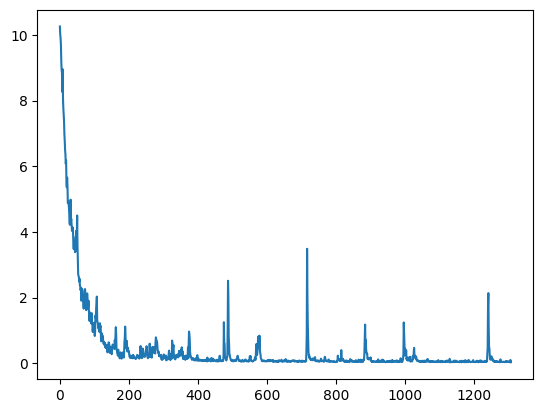

In [43]:
plt.plot(all_losses) 

In [44]:
model.eval()
with torch.no_grad():
    val_outputs = model(X_test_tensor).squeeze(-1)
    val_predictions = torch.sigmoid(val_outputs) > 0.5

In [49]:
val_predictions=val_predictions.cpu().numpy().astype(int)
val_predictions[:3]

array([1, 1, 1])

In [53]:
acc=(y_test_tensor.cpu().numpy()==val_predictions).mean()
acc

0.5748031496062992